L Slope:  [  1.57880949 -13.87465566  23.16300027  17.73889429 -45.27345296
  27.50550562  11.03261755  13.59633939  39.31678965   1.76799426]
L Intercept 151.6317280453258
rr Slope:  [  1.59182726 -13.85895389  23.17903383  17.72767274 -43.96306138
  26.49492408  10.42111336  13.39402273  38.79890667   1.76428031]
rr Intercept 151.6317280453258
rr1 Slope:  [  1.60412118 -13.84385075  23.19386032  17.71686576 -42.7273535
  25.54214831   9.84456973  13.20328153  38.31021861   1.76098541]
rr1 Intercept 151.6317280453258


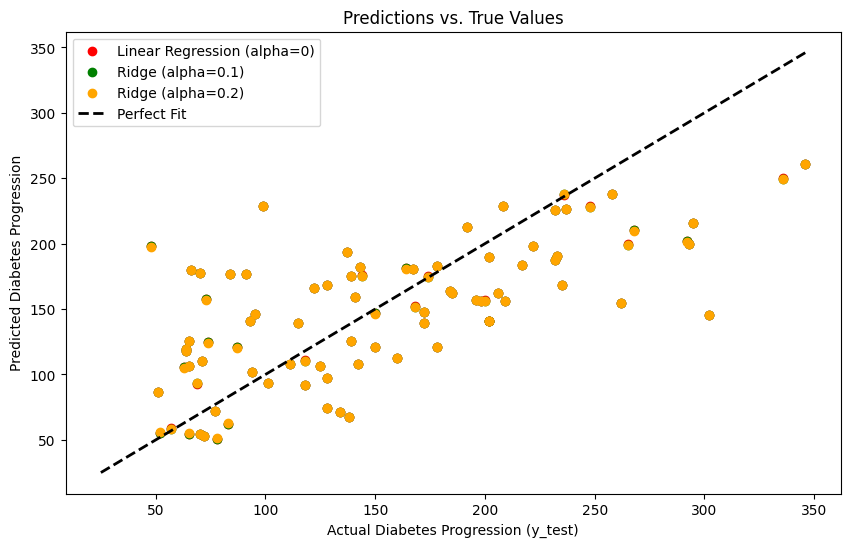

In [8]:
# This code is to compare the Linear regression and Ridge regression. which gives the best fit and with minimum error
# over below block you will get the code to get the automatic best alpha value is RidgeCV
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

# 1. Load and split data
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# 2. Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Use transform, NOT fit_transform here!

# Create and fit models
L = LinearRegression()
L.fit(X_train_scaled, y_train)

rr = Ridge(alpha=0.1, solver='cholesky')
rr.fit(X_train_scaled, y_train)

rr1 = Ridge(alpha=0.2, solver='cholesky')
rr1.fit(X_train_scaled, y_train)

# Get predictions from the models
# Get Predictions: The first step is to generate predictions 
# for each of your three trained models (L, rr, rr1) using the scaled test data (X_test_scaled).
L_predictions = L.predict(X_test_scaled)
rr_predictions = rr.predict(X_test_scaled)
rr1_predictions = rr1.predict(X_test_scaled)

print("L Slope: ",L.coef_)
print("L Intercept", L.intercept_)
print("rr Slope: ",rr.coef_)
print("rr Intercept", rr.intercept_)
print("rr1 Slope: ",rr1.coef_)
print("rr1 Intercept", rr1.intercept_)

# Plotting predictions vs. true values
plt.figure(figsize=(10, 6))
# The plt.scatter() function is used to plot the individual points. For each model, the actual y_test values are on the x-axis, 
#and the model's predictions are on the y-axis. The color and label arguments are used to differentiate the points from each model.
plt.scatter(y_test, L_predictions, color='red', label='Linear Regression (alpha=0)')
plt.scatter(y_test, rr_predictions, color='green', label='Ridge (alpha=0.1)')
plt.scatter(y_test, rr1_predictions, color='orange', label='Ridge (alpha=0.2)')

plt.title('Predictions vs. True Values')
plt.xlabel('Actual Diabetes Progression (y_test)')
plt.ylabel('Predicted Diabetes Progression')
# Perfect Fit Line: The plt.plot() function is used to draw a diagonal line. This is a visual reference representing 
# a perfect model where predicted values equal actual values.
# [y.min(), y.max()] Sets the x and y coordinates for the start and end of the line, ensuring it spans the entire data range.
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit') # A reference line
plt.legend()
plt.show()

The best alpha value found is: 1.072
Linear Regression MSE: 2939.36
Optimal Ridge Regression MSE: 2924.50


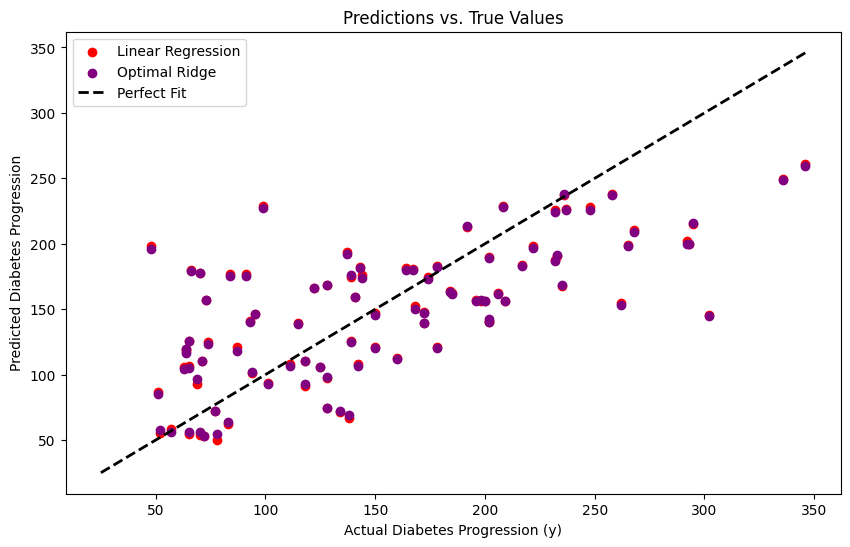

In [4]:
# This code is to compare the Linear regression and Ridge regression. which gives the best fit and with minimum error
# And in this block you will get the code to get the automatic best alpha value is RidgeCV
# Also comparing the MSE value between the Linear regression and Ridge regression predictions.
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error
# Use RidgeCV to find the best alpha
from sklearn.linear_model import RidgeCV
import numpy as np

# Load and split data
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
# 2. Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Use transform, NOT fit_transform here!

alphas_to_try = np.logspace(-3, 2, 100)
ridge_cv = RidgeCV(alphas=alphas_to_try)
ridge_cv.fit(X_train, y_train)

best_alpha = ridge_cv.alpha_
print(f"The best alpha value found is: {best_alpha:.3f}")

# Train models with their respective alphas
L = LinearRegression().fit(X_train, y_train)
rr_best = Ridge(alpha=best_alpha).fit(X_train, y_train)

# Get predictions from the models
L_predictions = L.predict(X_test)
rr_best_predictions = rr_best.predict(X_test)

# Calculate and print the Mean Squared Error (MSE)
mse_linear = mean_squared_error(y_test, L_predictions)
mse_ridge = mean_squared_error(y_test, rr_best_predictions)

print(f"Linear Regression MSE: {mse_linear:.2f}")
print(f"Optimal Ridge Regression MSE: {mse_ridge:.2f}")

# Plot Predictions vs. True Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, L_predictions, color='red', label='Linear Regression')
plt.scatter(y_test, rr_best_predictions, color='purple', label='Optimal Ridge')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')

plt.title('Predictions vs. True Values')
plt.xlabel('Actual Diabetes Progression (y)')
plt.ylabel('Predicted Diabetes Progression')
plt.legend()
plt.show()

__When using SGDRegressor, you need to decide on the penalty parameter based on the type of regularization you want to apply to your model.__

Here are the values you can use for the penalty parameter and what they mean:

'l2': This is the most common choice and is used for Ridge regression. It adds a penalty proportional to the square of the magnitude of the model's coefficients. This helps to prevent overfitting by shrinking the coefficients towards zero, but it won't force them to be exactly zero.

'l1': This is for Lasso regression. It adds a penalty proportional to the absolute value of the magnitude of the coefficients. A key feature of L1 regularization is that it can force some coefficients to become exactly zero, effectively performing feature selection by eliminating less important features from the model.

'elasticnet': This is for Elastic Net regularization. It is a hybrid of L1 and L2 regularization, meaning it applies both penalties. This is useful when you have many correlated features, as it combines the feature-selection ability of Lasso with the stability of Ridge. You can control the mix of L1 and L2 using the l1_ratio parameter.

'none': This means no regularization is applied. The model will perform the same as a standard LinearRegression model using gradient descent.

__The max_iter and tol parameters in SGDRegressor control when the training process stops. They work together to prevent the model from training indefinitely.__

max_iter
The max_iter parameter sets the maximum number of passes over the entire training data (also known as epochs).

Purpose: It's a safety net. It guarantees that the training loop will stop after a certain number of iterations, even if the convergence criteria (defined by tol) are not met. This prevents the training from running for an extremely long time if the model is struggling to converge.

Default Value: The default value is typically 1000. You might need to increase this for complex datasets or if the model isn't converging within the default number of iterations.

tol
The tol (short for tolerance) parameter sets a threshold for the change in the loss function. The training process will stop if the improvement in the loss function is less than this threshold for a certain number of consecutive iterations.

Purpose: It's a smart stopping criterion. It allows the training to stop early if the model has already converged and is no longer making significant progress. This saves computational time.

How it Works: The algorithm monitors the loss. If the change in loss from one iteration to the next is smaller than the tol value, it considers the model to have converged. The training then stops.

Default Value: The default value is 1e-3 (0.001).

Setting tol=None: If you set tol=None, the model will run for the full number of max_iter iterations, regardless of whether it has converged. This is useful for debugging or if you want to ensure the model trains for a specific, fixed number of epochs.

__How to Identify if You Need More Iterations__
The most direct way to identify this is by checking the training output for a ConvergenceWarning. This warning means that the model's loss function didn't improve by the tol (tolerance) threshold for a certain number of consecutive iterations before hitting the max_iter limit.

Here's how you can check and adjust for it:

Run the model with the default max_iter=1000.

Look for the ConvergenceWarning in your console output. It will typically say something like, "Liblinear failed to converge, increase the number of iterations."

If the warning appears, it means the model didn't have enough time to find an optimal solution. Your next step should be to increase max_iter to a larger value, like 2000, 5000, or even 10,000, and re-run the training.

Other Considerations
Learning Rate (eta0): A poor learning rate can also prevent convergence. If your learning rate is too small, the model will take tiny steps and may not converge within max_iter. If it's too large, it might overshoot the minimum.

Feature Scaling: As mentioned before, SGD is highly sensitive to feature scaling. If your features are not standardized (mean=0, variance=1), the optimization path can become very difficult for the algorithm, leading to slow or failed convergence. If you're getting a ConvergenceWarning, scaling your data with StandardScaler should be your first step.

The tol parameter: The tol parameter can also influence whether the algorithm converges within the iteration limit. A very small tol value means the algorithm needs to find a very precise solution, which may require more iterations to achieve.

__How to Choose: The best learning_rate is often found through trial and error. You can start with a common default value, such as 0.01, and then try different values, such as 0.1 and 0.001, to see how they affect convergence and model performance.__

The Problem with a Poor Learning Rate:

Too Small: The training will be very slow, and the model may not converge within the max_iter limit.

Too Large: The model might overshoot the optimal solution, causing the loss to diverge or jump around erratically.

Best Practice: Use scikit-learn's GridSearchCV or RandomizedSearchCV to automatically test a range of learning rates and find the one that works best for your data.



MSE with SGDRegressor (Ridge): 2966.17
MSE with standard Ridge: 2930.89


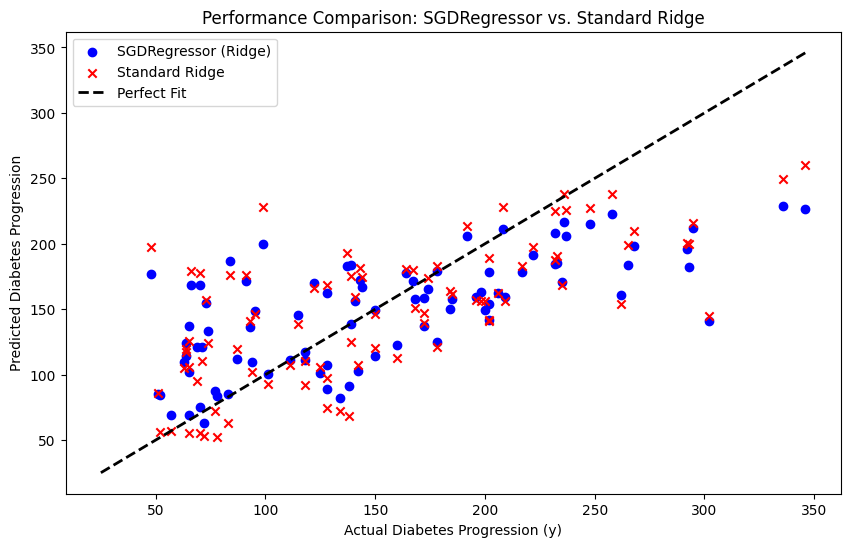

In [5]:
# In this block we are comparing the Ridge Regression using SGDRegressor(Gradient descent) and 
# Standard Ridge Regression (using the analytical solution)
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor, Ridge
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Load and prepare the data
X, y = load_diabetes(return_X_y=True)

# Standardize the data! SGD is very sensitive to feature scaling.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=4)

# Create an SGDRegressor instance
# 1. Ridge Regression using SGDRegressor
# 'l2' penalty for Ridge regression
# 'alpha' is the regularization strength
sgd_ridge = SGDRegressor(penalty='l2', alpha=0.5, max_iter=1000, tol=1e-3, random_state=42)
sgd_ridge.fit(X_train, y_train)
sgd_ridge_predictions = sgd_ridge.predict(X_test)
mse_sgd_ridge = mean_squared_error(y_test, sgd_ridge_predictions)
print(f"MSE with SGDRegressor (Ridge): {mse_sgd_ridge:.2f}")

# 2. Standard Ridge Regression (using the analytical solution) for comparison
ridge_solver = Ridge(alpha=0.5)
ridge_solver.fit(X_train, y_train)
ridge_solver_predictions = ridge_solver.predict(X_test)
mse_ridge_solver = mean_squared_error(y_test, ridge_solver_predictions)
print(f"MSE with standard Ridge: {mse_ridge_solver:.2f}")

# Plotting the predictions vs. true values to visualize performance
plt.figure(figsize=(10, 6))
plt.scatter(y_test, sgd_ridge_predictions, color='blue', label='SGDRegressor (Ridge)')
plt.scatter(y_test, ridge_solver_predictions, color='red', marker='x', label='Standard Ridge')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit')

plt.title('Performance Comparison: SGDRegressor vs. Standard Ridge')
plt.xlabel('Actual Diabetes Progression (y)')
plt.ylabel('Predicted Diabetes Progression')
plt.legend()
plt.show()

__GridSearchCV__

You are giving GridSearchCV the training data (X_train, y_train) and telling it to perform the entire search. During this process, GridSearchCV does the following:

It takes your X_train and y_train and splits them into cross-validation folds (e.g., 5 folds).

For each fold, it trains an SGDRegressor model using one of the hyperparameter combinations from your param_grid.

The model is trained on the training folds and evaluated on the held-out validation fold using the scoring metric you specified.

This is repeated for every combination of hyperparameters and every cross-validation fold.

Finally, GridSearchCV returns the best hyperparameters and the best-trained model (the best_estimator_), which is then ready to be evaluated on the separate, unseen X_test data.

__1. cv (Cross-Validation)__
The cv parameter determines the cross-validation strategy used to evaluate each hyperparameter combination. Instead of simply splitting the data once into training and validation sets, cv divides the data into multiple folds and performs the training-validation process multiple times.

How it works: For a value like cv=5 (the most common), GridSearchCV splits the training data into 5 equal parts (folds). It then iterates 5 times: in each iteration, it trains the model on 4 of the folds and validates it on the remaining fold. The final score for that hyperparameter combination is the average of the scores from all 5 iterations.

Purpose: This process provides a more robust and reliable estimate of the model's performance on unseen data. A single train/validation split can be noisy, but averaging the results from multiple splits helps to reduce this variance. It ensures that the model's performance isn't just a fluke based on a single data split. 

__2. Scoring__
The scoring parameter specifies the metric used to evaluate the model's performance on the validation data.

How it works: GridSearchCV uses this metric to decide which hyperparameter combination is the "best." For each combination, it calculates the score (e.g., R-squared, MSE, accuracy) on the validation fold(s) and uses this score to rank the different models.

Purpose: This allows you to choose the metric that is most relevant to your specific problem. For regression, common scoring metrics include:

'neg_mean_squared_error' (Negative Mean Squared Error): Since GridSearchCV tries to maximize the score, using the negative MSE means it will find the model with the lowest error.

'r2' (R-squared): A measure of how well the model's predictions fit the actual data.

For classification, common metrics include 'accuracy', 'f1_score', and 'roc_auc'.

__The combination of cv and scoring ensures that you find a set of hyperparameters that consistently perform well and are optimized for the most important metric for your project.__

In [131]:
# Below code will set alpha or eta0 (learning rate), using GridSearchCV. Rest is same as above.

import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

# Load and prepare the data
X, y = load_diabetes(return_X_y=True)

# It's crucial to standardize the data for SGDRegressor
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Create an SGDRegressor instance
# We will not set alpha or eta0 here, as GridSearchCV will handle it
sgd = SGDRegressor(penalty='l2', max_iter=5000, tol=1e-2, random_state=42)

# Define the grid of hyperparameters to search
param_grid = {
    'alpha': np.logspace(-4, 0, 5),  # Test alpha values from 0.0001 to 1
    'eta0': [0.001, 0.01, 0.1],      # Test initial learning rates
    'max_iter': [1000, 2000, 5000]   # Test different iteration limits
}

# Create a GridSearchCV object
# 'cv=5' means 5-fold cross-validation
# 'scoring' is the metric to optimize (we use negative MSE to find the lowest error)
grid_search = GridSearchCV(sgd, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best hyperparameters found: {best_params}")
print(f"Best cross-validation score (negative MSE): {best_score:.2f}")

# Train the final model with the best hyperparameters
best_sgd_model = grid_search.best_estimator_
print("grid_search.best_estimator_: ", grid_search.best_estimator_)

# Evaluate the final model on the test set
test_predictions = best_sgd_model.predict(X_test)
test_mse = mean_squared_error(y_test, test_predictions)
print(f"Test MSE with best hyperparameters: {test_mse:.2f}")

Best hyperparameters found: {'alpha': np.float64(0.1), 'eta0': 0.001, 'max_iter': 1000}
Best cross-validation score (negative MSE): -3120.05
grid_search.best_estimator_:  SGDRegressor(alpha=np.float64(0.1), eta0=0.001, random_state=42, tol=0.01)
Test MSE with best hyperparameters: 2868.84


__# Now to test whether you model is best trained__ 
Follow the below blocks.
1. Compare your model's MSE (which is test_mse) with baseline_mse. If your model's MSE is much lower than the baseline_mse, you're on the right track.
2. Check for Overfitting or Underfitting - By comparing training MSE and test MSE. If your train_mse and test_mse are close, your model is likely well-generalized.
3. Visualize the plots.

In [132]:
# Now to test whether you model is best trained
# Calculate the mean of the training target variable
y_train_mean = np.mean(y_train)

# Create a baseline model that always predicts the mean
baseline_predictions = np.full_like(y_test, y_train_mean)
# Calculate the Mean Squared Error for the baseline model
baseline_mse = mean_squared_error(y_test, baseline_predictions)
# If your model's MSE (which is test_mse 2868.84) is much lower than this baseline_mse, you're on the right track.
print(f"Baseline Mean Squared Error: {baseline_mse:.2f}")

Baseline Mean Squared Error: 5361.53


__Is It Overfitting or Underfitting?__
You also need to check if the model has a good balance between bias and variance.

Underfitting: This happens when the model is too simple to capture the underlying patterns in the data. The model performs poorly on both the training and test sets.

How to spot it: The training MSE will be high.

Overfitting: This happens when the model learns the training data's noise and details too well, performing great on the training set but poorly on the test set.

How to spot it: The training MSE is very low, but the test MSE is significantly higher.

You can check this by comparing the training and test scores of your best model:
train_predictions = best_sgd_model.predict(X_train)
train_mse = mean_squared_error(y_train, train_predictions)

If your train_mse and test_mse are close, your model is likely well-generalized.

In [133]:
# Get the training predictions from the best model
train_predictions = best_sgd_model.predict(X_train)
train_mse = mean_squared_error(y_train, train_predictions)

print(f"Training MSE: {train_mse:.2f}")
print(f"Test MSE: {test_mse:.2f}")

Training MSE: 2910.77
Test MSE: 2868.84


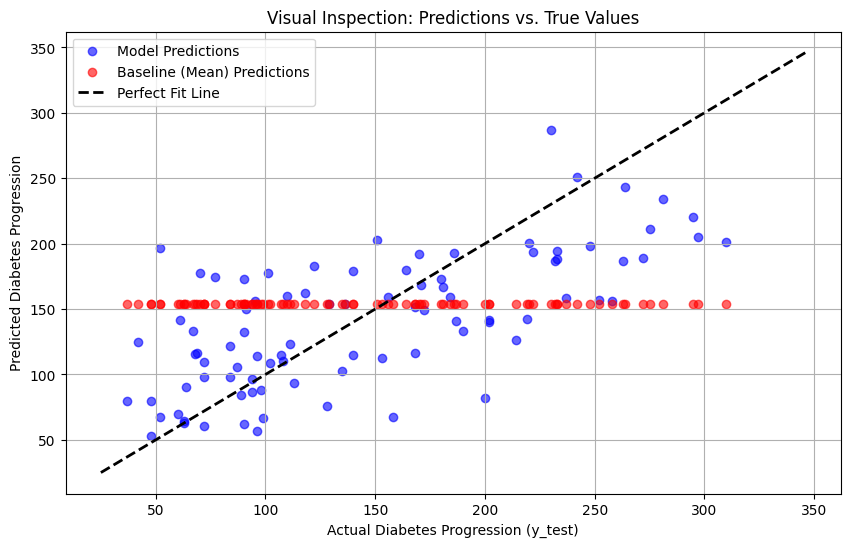

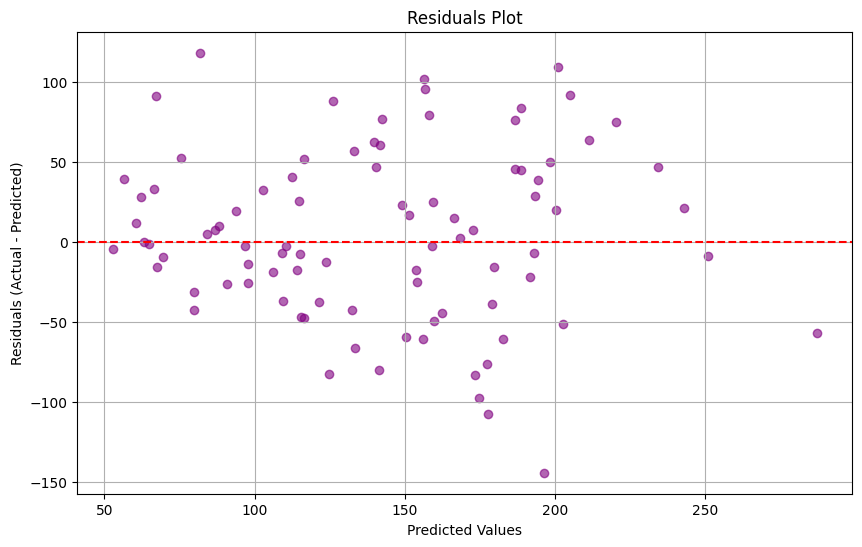

In [134]:
# Plot 1: Predictions vs. True Values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_predictions, color='blue', alpha=0.6, label='Model Predictions')
plt.scatter(y_test, baseline_predictions, color='red', alpha=0.6, label='Baseline (Mean) Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Perfect Fit Line')

plt.title('Visual Inspection: Predictions vs. True Values')
plt.xlabel('Actual Diabetes Progression (y_test)')
plt.ylabel('Predicted Diabetes Progression')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Residuals Plot
residuals = y_test - test_predictions
plt.figure(figsize=(10, 6))
plt.scatter(test_predictions, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.show()

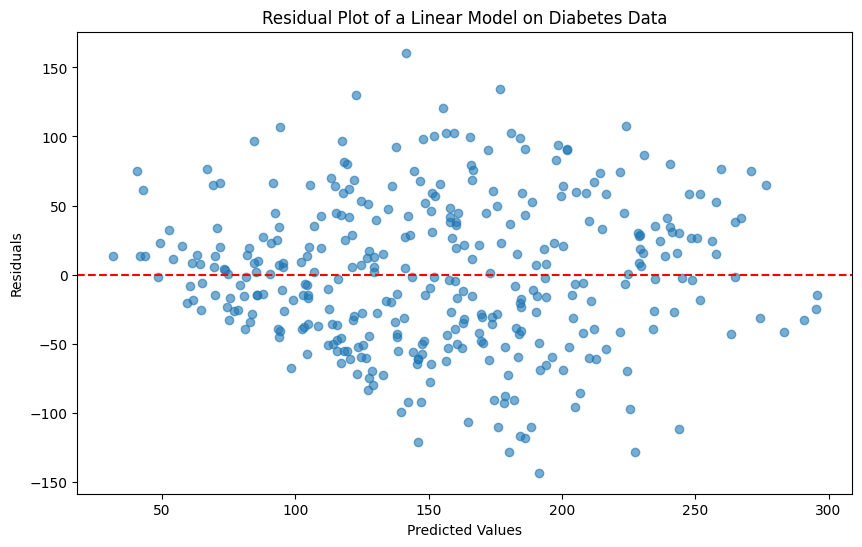

R-squared score on the test data: 0.4526


In [137]:
# Check whether data is linear or non linear
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Load and prepare the data
# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Step 2: Split the data into training and testing sets
# We use a test size of 20% for the test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Fit a Linear Regression model on the training data
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Make predictions on the training data
# We predict on the training data to create the residual plot
y_train_pred = model.predict(X_train)

# Step 5: Calculate and plot the residuals
# Residuals are the differences between the actual and predicted values
residuals = y_train - y_train_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_train_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot of a Linear Model on Diabetes Data')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# plot will around the line, will not give any curve or U shaped means linear data and we can use linear model.

# Step 6: Evaluate the model's performance on the unseen test data
y_test_pred = model.predict(X_test)
test_r2_score = r2_score(y_test, y_test_pred)
print(f"R-squared score on the test data: {test_r2_score:.4f}")

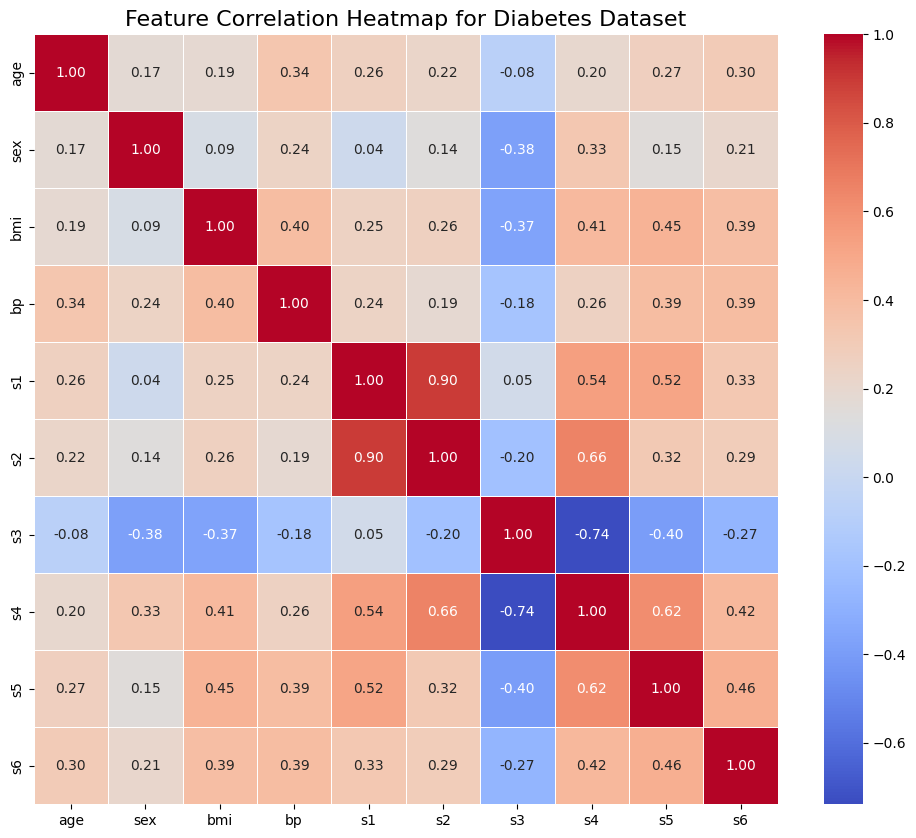

Correlation Matrix:
          age       sex       bmi        bp        s1        s2        s3  \
age  1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
sex  0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
bmi  0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
bp   0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
s1   0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
s2   0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
s3  -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
s4   0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
s5   0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
s6   0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   

           s4        s5        s6  
age  0.203841  0.270774  0.301731  
sex  0.332115  0.149916  0.208133  
bmi  0.413807  0.446157 

In [136]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_diabetes

# Load the data
diabetes_data = load_diabetes()
X = diabetes_data.data
y = diabetes_data.target
feature_names = diabetes_data.feature_names

# Convert to a pandas DataFrame for easier indexing
df = pd.DataFrame(X, columns=feature_names)

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation Heatmap for Diabetes Dataset', fontsize=16)
plt.show()

# Print a summary of the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Identify highly correlated pairs (e.g., |correlation| > 0.7)
high_corr_pairs = (correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
                      .stack()
                      .reset_index())
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs = high_corr_pairs[abs(high_corr_pairs['Correlation']) > 0.7]

print("\nHighly Correlated Feature Pairs (abs > 0.7):")
print(high_corr_pairs)

__Lasso regularization__

In [142]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
import pandas as pd

diabetes_data = load_diabetes()
X = diabetes_data.data
y = diabetes_data.target
feature_names = diabetes_data.feature_names

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Step 2. Fit a standard Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
# Step 3 Fit Lasso regression model
# The alpha parameter controls the strength of the penalty. A larger alpha
# leads to more coefficients being shrunk to zero.
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)

# Compare the coefficients
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression Coeff': lin_reg.coef_,
    'Lasso Regression Coeff': lasso_reg.coef_
})

print("Model Coefficients Comparison:")
print(coefficients_df)

# Step 5: Evaluate model performance
lin_reg_score = lin_reg.score(X_test, y_test)
lasso_reg_score = lasso_reg.score(X_test, y_test)

print("\n--- Model Performance ---")
print(f"Linear Regression R-squared: {lin_reg_score:.4f}")
print(f"Lasso Regression R-squared: {lasso_reg_score:.4f}")

# Step 6: Predict 
lin_y_pred = lin_reg.predict(X_test)
lasso_y_pred = lasso_reg.predict(X_test)
print("lin_y_pred: ", lin_y_pred)

plt.figure(figsize=(10, 6))
plt.scatter(y_train_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot of a Linear Model on Diabetes Data')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()


Model Coefficients Comparison:
  Feature  Linear Regression Coeff  Lasso Regression Coeff
0     age                 1.753758                1.730451
1     sex               -11.511809              -11.316359
2     bmi                25.607121               25.824627
3      bp                16.828872               16.644252
4      s1               -44.448856              -29.358412
5      s2                24.640954               13.275844
6      s3                 7.676978                0.547948
7      s4                13.138784               10.236168
8      s5                35.161195               29.632826
9      s6                 2.351364                2.393475

--- Model Performance ---
Linear Regression R-squared: 0.4526
Lasso Regression R-squared: 0.4555
lin_y_pred:  [139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858
  94.13865744 168.43486358  53.5047888  206.63081659 100.12925869
 130.666570